In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ast

In [2]:
ds_path = "./output/02_imdb.csv"

def load_data():
    return pd.read_csv(ds_path, na_values=['\\N'])
ds = load_data()

# Label encoding


In [3]:
def label_encoding(column, ds):
    mapping = {}
    count = 0
    # Crea il mapping
    for i in range(len(ds)):
        if pd.isna(ds[column][i]):
            continue
        if ds[column][i] not in mapping:
            mapping[ds[column][i]] = count
            count += 1
    # Applica il mapping alla colonna
    ds[column] = ds[column].map(mapping)
    # Salva il mapping in un file
    with open(f"./output/{column}_label_encoding.txt", "w") as f:
        f.write(str(mapping))
    return ds

ds = label_encoding("titleType", ds)


# One-hot encoding

In [4]:
def custom_one_hot_encoding(df, col, prefix, output_file="./generated_columns.txt"):
    """
    Esegue il one-hot encoding di una colonna, gestendo valori multipli in liste rappresentate come stringhe.
    Salva le colonne generate in un file di testo nel formato di una lista Python.

    Args:
    df (pd.DataFrame): DataFrame di input.
    col (str): Nome della colonna da codificare.
    prefix (str): Prefisso per le nuove colonne.
    output_file (str): Percorso del file di output per salvare le colonne generate.

    Returns:
    pd.DataFrame: DataFrame con colonne one-hot encoded e una colonna di conteggio.
    """
    # Step 1: Creazione del set di valori univoci
    unique_values = set()
    for row in df[col]:
        if isinstance(row, str):  # Controlla che la riga sia una stringa
            cleaned_row = row.replace("[", "").replace("]", "").replace("'", "").strip()
            unique_values.update(cleaned_row.split(","))

    unique_values = {val.strip() for val in unique_values if val.strip()}  # Rimuove spazi vuoti e valori vuoti

    # Step 2: Creazione delle colonne one-hot
    generated_columns = []
    for value in unique_values:
        column_name = f"{prefix}{value}"
        df[column_name] = 0  # Inizializza le colonne con 0
        generated_columns.append(column_name)

    # Step 3: Assegnazione degli 1 dove necessario
    for index, row in df.iterrows():
        if isinstance(row[col], str):  # Controlla che la riga sia una stringa
            cleaned_row = row[col].replace("[", "").replace("]", "").replace("'", "").strip()
            values = {val.strip() for val in cleaned_row.split(",") if val.strip()}
            for value in values:
                if value in unique_values:
                    df.at[index, f"{prefix}{value}"] = 1

    # Step 5: Salva le colonne generate in un file di testo nel formato di una lista Python
    with open(output_file, "w") as f:
        f.write("[\n")
        for column in generated_columns:
            f.write(f"    '{column}',\n")
        f.write("]\n")

    # Rimuove la colonna originale
    df.drop(columns=[col], inplace=True)
    print(f"Generated columns saved to {output_file} in list format")
    return df

### Origin

In [5]:
ds=custom_one_hot_encoding(ds, "regionOfOrigin", "origin", output_file="./output/regionOfOrigin_one_hot.txt")
print("Done.")

Generated columns saved to ./output/regionOfOrigin_one_hot.txt in list format
Done.


### Available

In [6]:
ds=custom_one_hot_encoding(ds, "regionAvailability", "available", output_file="./output/regionAvailability_one_hot.txt")
print("Done.")

Generated columns saved to ./output/regionAvailability_one_hot.txt in list format
Done.


### Genres

In [7]:
custom_one_hot_encoding(ds, "genres", "genre", output_file="./output/genres_one_hot.txt")
print("Done.")

Generated columns saved to ./output/genres_one_hot.txt in list format
Done.


In [8]:
#show attributes list
print(ds.columns)

Index(['originalTitle', 'rating', 'numVotes', 'totalCredits',
       'criticReviewsTotal', 'titleType', 'isAdult', 'userReviewsTotal',
       'castNumber', 'companiesNumber', 'averageRating', 'writerCredits',
       'directorsCredits', 'quotesTotal', 'startYearDecade', 'totalMedia',
       'totalRecognitions', 'runtimeHours', 'originSouth-easternAsia',
       'originNorthernAmerica', 'originAustraliaandNewZealand',
       'originCaribbean', 'originEasternAfrica', 'originMelanesia',
       'originMicronesia', 'originSouthernAsia', 'originMiddleAfrica',
       'originCentralAsia', 'originSouthernEurope', 'originNorthernEurope',
       'originUnknown', 'originPolynesia', 'originSouthernAfrica',
       'originCentralAmerica', 'originWesternEurope', 'originWesternAsia',
       'originNorthernAfrica', 'originSouthAmerica', 'originEasternEurope',
       'originWesternAfrica', 'originEasternAsia',
       'availableSouth-easternAsia', 'availableNorthernAmerica',
       'availableAustraliaandNew

In [9]:
# check number of rows with isAdult = 0 and Adult = 0 
# check number of rows with isAdult = 1 and Adult = 1
# check number of rows with isAdult = 0 and Adult = 1
# check number of rows with isAdult = 1 and Adult = 0

print("isAdult = 0 and Adult = 0: ", len(ds[(ds["isAdult"] == 0) & (ds["genreAdult"] == 0)]))
print("isAdult = 1 and Adult = 1: ", len(ds[(ds["isAdult"] == 1) & (ds["genreAdult"] == 1)]))
print("isAdult = 0 and Adult = 1: ", len(ds[(ds["isAdult"] == 0) & (ds["genreAdult"] == 1)]))
print("isAdult = 1 and Adult = 0: ", len(ds[(ds["isAdult"] == 1) & (ds["genreAdult"] == 0)]))


isAdult = 0 and Adult = 0:  142502
isAdult = 1 and Adult = 1:  2637
isAdult = 0 and Adult = 1:  0
isAdult = 1 and Adult = 0:  40


In [10]:
# if isAdult 1 and Adult 0, set Adult = 1
ds.loc[(ds["isAdult"] == 1) & (ds["genreAdult"] == 0), "genreAdult"] = 1


In [11]:
print("isAdult = 0 and Adult = 0: ", len(ds[(ds["isAdult"] == 0) & (ds["genreAdult"] == 0)]))
print("isAdult = 1 and Adult = 1: ", len(ds[(ds["isAdult"] == 1) & (ds["genreAdult"] == 1)]))
print("isAdult = 0 and Adult = 1: ", len(ds[(ds["isAdult"] == 0) & (ds["genreAdult"] == 1)]))
print("isAdult = 1 and Adult = 0: ", len(ds[(ds["isAdult"] == 1) & (ds["genreAdult"] == 0)]))

isAdult = 0 and Adult = 0:  142502
isAdult = 1 and Adult = 1:  2677
isAdult = 0 and Adult = 1:  0
isAdult = 1 and Adult = 0:  0


In [12]:
# drop isAdult
ds.drop(columns=["isAdult", "genreShort"], inplace=True)

In [13]:
# store in output_ds/03_imdb.csv
ds.to_csv("./output/03_imdb.csv", index=False)

In [14]:
# print columns names in a
print(ds.columns)

Index(['originalTitle', 'rating', 'numVotes', 'totalCredits',
       'criticReviewsTotal', 'titleType', 'userReviewsTotal', 'castNumber',
       'companiesNumber', 'averageRating', 'writerCredits', 'directorsCredits',
       'quotesTotal', 'startYearDecade', 'totalMedia', 'totalRecognitions',
       'runtimeHours', 'originSouth-easternAsia', 'originNorthernAmerica',
       'originAustraliaandNewZealand', 'originCaribbean',
       'originEasternAfrica', 'originMelanesia', 'originMicronesia',
       'originSouthernAsia', 'originMiddleAfrica', 'originCentralAsia',
       'originSouthernEurope', 'originNorthernEurope', 'originUnknown',
       'originPolynesia', 'originSouthernAfrica', 'originCentralAmerica',
       'originWesternEurope', 'originWesternAsia', 'originNorthernAfrica',
       'originSouthAmerica', 'originEasternEurope', 'originWesternAfrica',
       'originEasternAsia', 'availableSouth-easternAsia',
       'availableNorthernAmerica', 'availableAustraliaandNewZealand',
       '

In [15]:
col_to_check = [
    'numVotes', 
    'totalCredits', 
    'criticReviewsTotal',
    'userReviewsTotal',
    'castNumber',
    'companiesNumber',
    'writerCredits',
    'directorsCredits',
    'quotesTotal',
    'totalMedia',
    'totalRecognitions']

    num_zeros  count
8           0   2748
5           1  10551
3           2  17141
2           3  22968
0           4  34801
1           5  27714
4           6  16963
6           7   8411
7           8   2909
9           9    651
10         10    322
Total records: 145179


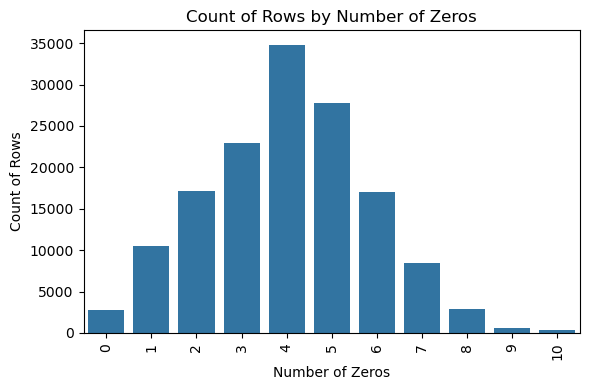

In [17]:
# count how many zeros are in each row for col_to_check
# then group by the number of zeros and count how many rows have that number of zeros
count_zeros = ds[col_to_check].apply(lambda x: (x == 0).sum(), axis=1)
count_zeros_counts = count_zeros.value_counts().reset_index()
count_zeros_counts.columns = ['num_zeros', 'count']
# sort by num_zeros
count_zeros_counts.sort_values(by='num_zeros', inplace=True)
# plot the results
plt.figure(figsize=(6, 4))
sns.barplot(data=count_zeros_counts, x='num_zeros', y='count')
plt.title('Count of Rows by Number of Zeros')
plt.xlabel('Number of Zeros')
plt.ylabel('Count of Rows')
plt.xticks(rotation=90)
plt.tight_layout()

# print  a table with number of zeros: number of rows
print(count_zeros_counts)

# print total records by summing count
total_records = count_zeros_counts['count'].sum()
print(f"Total records: {total_records}")


FileNotFoundError: [Errno 2] No such file or directory: '../imdb/data_overview/misc/count_zeros_by_column.png'

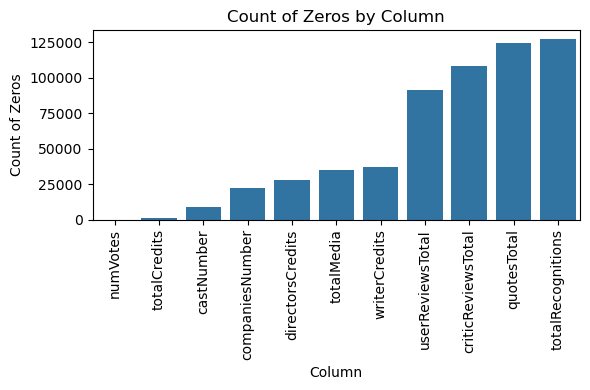

In [18]:
# count number of zeros in each column
count_zeros = ds[col_to_check].apply(lambda x: (x == 0).sum(), axis=0)
count_zeros_counts = count_zeros.reset_index()
count_zeros_counts.columns = ['column', 'num_zeros']
# sort by num_zeros
count_zeros_counts.sort_values(by='num_zeros', inplace=True)
# plot the results
plt.figure(figsize=(6, 4))
sns.barplot(data=count_zeros_counts, x='column', y='num_zeros')
plt.title('Count of Zeros by Column')
plt.xlabel('Column')
plt.ylabel('Count of Zeros')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../imdb/data_overview/misc/count_zeros_by_column.png")
# print  a table with number of zeros: number of rows
print(count_zeros_counts)
# print total records by summing count
total_records = count_zeros_counts['num_zeros'].sum()
print(f"Total records: {total_records}")


    num_ones   count
1          0   39787
0          1  100171
2          2    4340
3          3     681
4          4     139
5          5      43
6          6      10
8          7       3
7          8       3
9         13       1
10        14       1
Total records: 145179


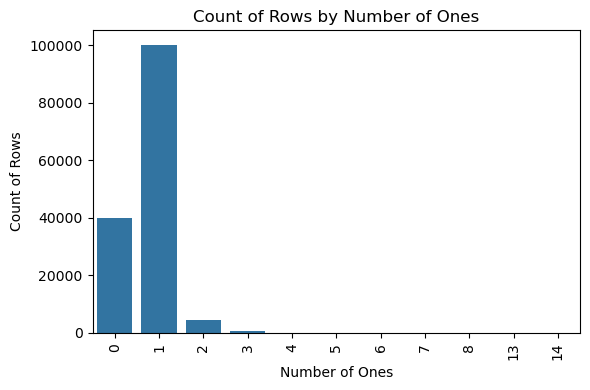

In [ ]:
region_list = [
    'originCaribbean',
    'originMelanesia',
    'originSouthAmerica',
    'originPolynesia',
    'originWesternAfrica',
    'originNorthernEurope',
    'originCentralAmerica',
    'originEasternAsia',
    'originMiddleAfrica',
    'originWesternEurope',
    'originNorthernAfrica',
    'originAustraliaandNewZealand',
    'originSouthernAfrica',
    'originEasternEurope',
    'originNorthernAmerica',
    'originEasternAfrica',
    'originSouthernAsia',
    'originSouthernEurope',
    'originMicronesia',
    'originSouth-easternAsia',
    'originCentralAsia',
    'originWesternAsia'
]


# check how many 1s are in each column. Group by the number of 1s and count how many rows have that number of 1s
count_ones = ds[region_list].apply(lambda x: (x == 1).sum(), axis=1)
count_ones_counts = count_ones.value_counts().reset_index()
count_ones_counts.columns = ['num_ones', 'count']
# sort by num_ones
count_ones_counts.sort_values(by='num_ones', inplace=True)
# plot the results
plt.figure(figsize=(6, 4))
sns.barplot(data=count_ones_counts, x='num_ones', y='count')
plt.title('Count of Rows by Number of Ones')
plt.xlabel('Number of Ones')
plt.ylabel('Count of Rows')
plt.xticks(rotation=90)
plt.tight_layout()
# print  a table with number of ones: number of rows
print(count_ones_counts)
# print total records by summing count
total_records = count_ones_counts['count'].sum()
print(f"Total records: {total_records}")

    num_ones  count
1          0  34661
0          1  63108
4          2   9994
5          3   4632
3          4  10981
6          5   2304
7          6   1874
8          7   1519
9          8   1199
10         9    965
11        10    776
12        11    494
15        12    321
14        13    333
13        14    350
16        15    105
17        16      6
19        17      4
18        18      6
20        19      2
2         22  11545
Total records: 145179


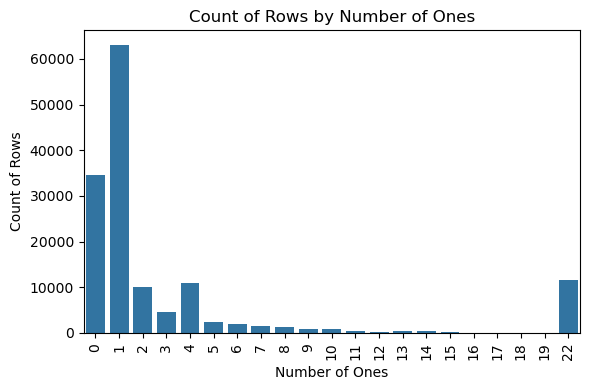

In [ ]:
region_availability_list = [
    'availableCaribbean',
    'availableMelanesia',
    'availableSouthAmerica',
    'availablePolynesia',
    'availableWesternAfrica',
    'availableNorthernEurope',
    'availableCentralAmerica',
    'availableEasternAsia',
    'availableMiddleAfrica',
    'availableWesternEurope',
    'availableNorthernAfrica',
    'availableAustraliaandNewZealand',
    'availableSouthernAfrica',
    'availableEasternEurope',
    'availableNorthernAmerica',
    'availableEasternAfrica',
    'availableSouthernAsia',
    'availableSouthernEurope',
    'availableMicronesia',
    'availableSouth-easternAsia',
    'availableCentralAsia',
    'availableWesternAsia',
]
# check how many 1s are in each column. Group by the number of 1s and count how many rows have that number of 1s
count_ones = ds[region_availability_list].apply(lambda x: (x == 1).sum(), axis=1)
count_ones_counts = count_ones.value_counts().reset_index()
count_ones_counts.columns = ['num_ones', 'count']
# sort by num_ones
count_ones_counts.sort_values(by='num_ones', inplace=True)
# plot the results
plt.figure(figsize=(6, 4))
sns.barplot(data=count_ones_counts, x='num_ones', y='count')
plt.title('Count of Rows by Number of Ones')
plt.xlabel('Number of Ones')
plt.ylabel('Count of Rows')
plt.xticks(rotation=90)
plt.tight_layout()
# print  a table with number of ones: number of rows
print(count_ones_counts)
# print total records by summing count
total_records = count_ones_counts['count'].sum()
print(f"Total records: {total_records}")